In [1]:
import pandas as pd
import numpy as np
calendar = pd.read_csv('./data/calendar.csv.gz', compression='gzip')
listings = pd.read_csv('./data/listings.csv')
neighbourhoods = pd.read_csv('./data/neighbourhoods.csv')
reviews = pd.read_csv('./data/reviews.csv')

In [2]:
import json 
with open('./data/neighbourhoods.geojson', 'r') as f:
    data = json.load(f)

# 구조 확인
print(type(data))
print(data.keys())
print(data['type'])
print(f"총 지역 수: {len(data['features'])}")

# 첫 번째 feature 보기
print(data['features'][0])

<class 'dict'>
dict_keys(['type', 'features'])
FeatureCollection
총 지역 수: 50
{'type': 'Feature', 'geometry': {'type': 'MultiPolygon', 'coordinates': [[[[100.516493, 13.800335], [100.516219, 13.799223], [100.515842, 13.798222], [100.515279, 13.797133], [100.514119, 13.79557], [100.512245, 13.793358], [100.510371, 13.79121], [100.508393, 13.789253], [100.508307, 13.789167], [100.507969, 13.788834], [100.505872, 13.786377], [100.505823, 13.786319], [100.505747, 13.786229], [100.505441, 13.785872], [100.50384, 13.783732], [100.502574, 13.781174], [100.502519, 13.781036], [100.502488, 13.780969], [100.50009, 13.775305], [100.499043, 13.772909], [100.498377, 13.771386], [100.497234, 13.768846], [100.496962, 13.768241], [100.494929, 13.765671], [100.494073, 13.764806], [100.4933, 13.764032], [100.490997, 13.761907], [100.485451, 13.769363], [100.485326, 13.769517], [100.485049, 13.769873], [100.484504, 13.770596], [100.484184, 13.770999], [100.483373, 13.77202], [100.482857, 13.772676], [100.4

In [3]:
def audit_dataframe(df):
    
    print("=" * 60)
    print("1. BASIC INFO")
    print("=" * 60)
    print(f"Shape: {df.shape}")
    print(f"Total cells: {df.shape[0] * df.shape[1]:,}")
    print()
    
    print("=" * 60)
    print("2. DATA TYPES")
    print("=" * 60)
    print(df.dtypes)
    print()
    
    print("=" * 60)
    print("3. MISSING VALUES")
    print("=" * 60)
    missing = pd.DataFrame({
        'missing_count': df.isnull().sum(),
        'missing_%': (df.isnull().sum() / len(df) * 100).round(2)
    })
    missing = missing[missing['missing_count'] > 0].sort_values('missing_%', ascending=False)
    
    if missing.empty:
        print("No missing values found!")
    else:
        print(missing)
    print()
    
    print("=" * 60)
    print("4. DUPLICATES")
    print("=" * 60)
    print(f"Duplicate rows: {df.duplicated().sum()}")
    print()
    
    print("=" * 60)
    print("5. NUMERIC COLUMNS — OUTLIER CHECK")
    print("=" * 60)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
        print(f"{col}: {len(outliers)} outliers | min={df[col].min()} max={df[col].max()} mean={df[col].mean():.2f}")
    print()
    
    print("=" * 60)
    print("6. CATEGORICAL COLUMNS — CARDINALITY CHECK")
    print("=" * 60)
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    for col in cat_cols:
        print(f"{col}: {df[col].nunique()} unique values | sample: {df[col].dropna().unique()[:5]}")
    print()
    
    print("=" * 60)
    print("7. SUSPECTED TYPE MISMATCHES")
    print("=" * 60)
    for col in df.select_dtypes(include='object').columns:
        # 숫자처럼 생긴 string 컬럼 탐지
        sample = df[col].dropna().head(100)
        try:
            pd.to_numeric(sample)
            print(f"[!] '{col}' is object but looks numeric — consider casting")
        except:
            pass
        # 날짜처럼 생긴 string 컬럼 탐지
        if any(keyword in col.lower() for keyword in ['date', 'time', 'at', 'day']):
            print(f"[!] '{col}' name suggests datetime but dtype is object — consider pd.to_datetime()")
    
    print()
    print("Audit complete.")


In [4]:
audit_dataframe(calendar)

1. BASIC INFO
Shape: (10514202, 7)
Total cells: 73,599,414

2. DATA TYPES
listing_id          int64
date               object
available          object
price             float64
adjusted_price    float64
minimum_nights      int64
maximum_nights      int64
dtype: object

3. MISSING VALUES
                missing_count  missing_%
price                10514202      100.0
adjusted_price       10514202      100.0

4. DUPLICATES
Duplicate rows: 0

5. NUMERIC COLUMNS — OUTLIER CHECK
listing_id: 0 outliers | min=27934 max=1518168294097881222 mean=799504015942602368.00
price: 0 outliers | min=nan max=nan mean=nan
adjusted_price: 0 outliers | min=nan max=nan mean=nan
minimum_nights: 426852 outliers | min=1 max=1115 mean=14.01
maximum_nights: 6198 outliers | min=1 max=2147483647 mean=595615.42

6. CATEGORICAL COLUMNS — CARDINALITY CHECK
date: 367 unique values | sample: ['2025-09-27' '2025-09-26' '2025-09-28' '2025-09-29' '2025-09-30']
available: 2 unique values | sample: ['f' 't']

7. SUSPECTED 

In [5]:
print(calendar['price'][0], calendar['adjusted_price'][0])

nan nan


In [6]:
calendar['adjusted_price']

0          NaN
1          NaN
2          NaN
3          NaN
4          NaN
            ..
10514197   NaN
10514198   NaN
10514199   NaN
10514200   NaN
10514201   NaN
Name: adjusted_price, Length: 10514202, dtype: float64

In [7]:
calendar.drop(columns=['price', 'adjusted_price'], inplace=True)
calendar['date'] = pd.to_datetime(calendar['date'])

In [8]:
audit_dataframe(listings)

1. BASIC INFO
Shape: (28806, 79)
Total cells: 2,275,674

2. DATA TYPES
id                                                int64
listing_url                                      object
scrape_id                                         int64
last_scraped                                     object
source                                           object
                                                 ...   
calculated_host_listings_count                    int64
calculated_host_listings_count_entire_homes       int64
calculated_host_listings_count_private_rooms      int64
calculated_host_listings_count_shared_rooms       int64
reviews_per_month                               float64
Length: 79, dtype: object

3. MISSING VALUES
                              missing_count  missing_%
license                               28806     100.00
neighbourhood_group_cleansed          28806     100.00
calendar_updated                      28806     100.00
host_neighbourhood                    19436     

In [9]:
pd.set_option('display.max_columns', None)

print(listings.columns.tolist())


['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availabil

In [10]:
listings['bathrooms_text']
from collections import Counter
print(Counter(listings['bathrooms_text']))

Counter({'1 bath': 14647, '1 private bath': 5469, '2 baths': 3199, '1.5 baths': 1105, '1 shared bath': 1044, '3 baths': 687, '2.5 baths': 335, '4 baths': 334, '2 shared baths': 266, '3.5 baths': 196, '5 baths': 130, nan: 122, '3 shared baths': 122, '0 shared baths': 104, '6 baths': 98, 'Shared half-bath': 97, '4.5 baths': 95, '1.5 shared baths': 93, 'Half-bath': 80, '4 shared baths': 80, '0 baths': 70, 'Private half-bath': 68, '8 shared baths': 39, '2.5 shared baths': 37, '7 baths': 37, '5.5 baths': 33, '8 baths': 26, '6 shared baths': 26, '3.5 shared baths': 25, '5 shared baths': 18, '4.5 shared baths': 15, '7 shared baths': 14, '6.5 baths': 12, '10 baths': 11, '9 baths': 9, '10 shared baths': 6, '5.5 shared baths': 6, '8.5 baths': 6, '7.5 baths': 5, '6.5 shared baths': 4, '9.5 baths': 4, '15 baths': 3, '12 baths': 3, '12 shared baths': 2, '11 baths': 2, '12.5 baths': 2, '28 baths': 2, '16 baths': 2, '20 shared baths': 1, '23 baths': 1, '40 baths': 1, '9 shared baths': 1, '30 baths': 

In [11]:
print(Counter(listings['bathrooms']))

Counter({1.0: 16914, 2.0: 2923, 1.5: 971, 3.0: 692, 4.0: 344, 2.5: 333, 3.5: 206, 0.5: 188, 0.0: 145, 5.0: 123, 6.0: 108, 4.5: 88, 8.0: 42, 7.0: 41, 5.5: 28, 10.0: 15, 6.5: 14, 9.0: 8, 8.5: 7, 7.5: 6, 12.0: 5, 9.5: 4, 11.0: 2, 12.5: 2, 15.0: 2, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan: 1, nan

In [12]:
listings[listings['bathrooms'].isna()]

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
1,27979,https://www.airbnb.com/rooms/27979,20250926165947,2025-09-27,previous scrape,"Easy going landlord,easy place",NaN,NaN,https://a0.muscache.com/pictures/106247594/1d6...,120541,https://www.airbnb.com/users/show/120541,Emy,2010-05-08,"Bangkok, Thailand",NaN,NaN,NaN,NaN,f,https://a0.muscache.com/im/users/120541/profil...,https://a0.muscache.com/im/users/120541/profil...,NaN,2.0,4.0,"['email', 'phone']",t,f,NaN,Bang Na,NaN,13.668180,100.616740,Private room in rental unit,Private room,2,NaN,1 bath,NaN,NaN,"[""Essentials"", ""Heating"", ""Free parking on pre...",NaN,1,730,1.0,1.0,730.0,730.0,1.0,730.0,NaN,NaN,0,0,0,0,2025-09-27,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,2,1,1,0,NaN
2,28745,https://www.airbnb.com/rooms/28745,20250926165947,2025-09-27,previous scrape,modern-style apartment in Bangkok,A modern-style apartment situated in a cool ne...,Ramkumheang neigbourhood - hip place with food...,https://a0.muscache.com/pictures/160369/92a7ec...,123784,https://www.airbnb.com/users/show/123784,Familyroom,2010-05-12,"Bangkok, Thailand",Welcome to Familyroom Apartment.\r\n\r\nA Chic...,NaN,NaN,NaN,f,https://a0.muscache.com/im/users/123784/profil...,https://a0.muscache.com/im/users/123784/profil...,Bang Kapi,1.0,1.0,"['email', 'phone']",t,f,"Bangkok, Thailand",Bang Kapi,NaN,13.752320,100.624020,Private room in rental unit,Private room,2,NaN,1 bath,1.0,NaN,[],NaN,60,730,60.0,60.0,730.0,730.0,60.0,730.0,NaN,NaN,0,0,0,0,2025-09-27,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,1,0,1,0,NaN
3,47516,https://www.airbnb.com/rooms/47516,20250926165947,2025-09-27,city scrape,Beautiful waterfront house,NaN,NaN,https://a0.muscache.com/pictures/271998/b090ad...,214456,https://www.airbnb.com/users/show/214456,Anuradha,2010-08-27,"New Delhi, India",NaN,NaN,NaN,NaN,f,https://a0.muscache.com/defaults/user_pic-50x5...,https://a0.muscache.com/defaults/user_pic-225x...,NaN,1.0,2.0,"['email', 'phone']",f,t,NaN,Don Mueang,NaN,13.927260,100.585290,Entire home,Entire home/apt,1,NaN,NaN,4.0,1.0,"[""Free parking on premises"", ""Kitchen"", ""Pets ...","$4,188.00",3,730,3.0,3.0,730.0,730.0,3.0,730.0,NaN,NaN,30,60,90,365,2025-09-27,0,0,0,96,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,1,1,0,0,NaN
6,62217,https://www.airbnb.com/rooms/62217,20250926165947,2025-09-27,previous scrape,Luxury@swimpool/FreeWiFi/nearJJMkt,NaN,NaN,https://a0.muscache.com/pictures/380405/13f241...,302658,https://www.airbnb.com/users/show/302658,Srisuk,2010-11-28,Thailand,I live in the main house with friends :) Welco...,NaN,NaN,NaN,f,https://a0.muscache.com/im/users/3

In [13]:
listings['bathrooms'].isna().sum()

np.int64(5589)

In [14]:
listings[listings['bathrooms'].isna()][['id', 'name', 'neighbourhood', 'bathrooms']]  # Pick relevant columns

,id,name,neighbourhood,bathrooms
1,27979,"Easy going landlord,easy place",NaN,NaN
2,28745,modern-style apartment in Bangkok,"Bangkok, Thailand",NaN
3,47516,Beautiful waterfront house,NaN,NaN
6,62217,Luxury@swimpool/FreeWiFi/nearJJMkt,NaN,NaN
11,1019241,Chic two bedroom for Monthly rental,"Bangkok, Thailand",NaN
...,...,...,...,...
28198,1501210646617804826,Happy room,NaN,NaN
28352,1506097605824811150,Cozy city near BTS 300m,NaN,NaN
28443,1507237596303712755,JC Kevin Sathorn Bangkok Hotel is a 5-star hotel,NaN,NaN
28553,1514167517198704332,Sheikh stay in superior white,NaN,NaN


In [15]:
audit_dataframe(neighbourhoods)

1. BASIC INFO
Shape: (50, 2)
Total cells: 100

2. DATA TYPES
neighbourhood_group    float64
neighbourhood           object
dtype: object

3. MISSING VALUES
                     missing_count  missing_%
neighbourhood_group             50      100.0

4. DUPLICATES
Duplicate rows: 0

5. NUMERIC COLUMNS — OUTLIER CHECK
neighbourhood_group: 0 outliers | min=nan max=nan mean=nan

6. CATEGORICAL COLUMNS — CARDINALITY CHECK
neighbourhood: 50 unique values | sample: ['Bang Bon' 'Bang Kapi' 'Bang Khae' 'Bang Khen' 'Bang Kho laen']

7. SUSPECTED TYPE MISMATCHES

Audit complete.


In [16]:
neighbourhoods.head()

,neighbourhood_group,neighbourhood
0,NaN,Bang Bon
1,NaN,Bang Kapi
2,NaN,Bang Khae
3,NaN,Bang Khen
4,NaN,Bang Kho laen


In [17]:
reviews.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,27934,1094339,2012-04-07,1368195,Michael,We stayed in the apartment for a week and we e...
1,27934,1241042,2012-05-07,2007324,Scott,My girlfriend and I recently stayed in Nuttee'...
2,27934,1523384,2012-06-20,2263352,Marc,I stayed for one month at the condo and was re...
3,27934,1655571,2012-07-08,558987,Leyla,Nuttee was a great host! I really enjoyed her ...
4,27934,1972192,2012-08-13,2359865,Rachel,Nuttee was an amazing host. She and her daught...


In [18]:
audit_dataframe(reviews)

1. BASIC INFO
Shape: (583333, 6)
Total cells: 3,499,998

2. DATA TYPES
listing_id        int64
id                int64
date             object
reviewer_id       int64
reviewer_name    object
comments         object
dtype: object

3. MISSING VALUES
               missing_count  missing_%
comments                  70       0.01
reviewer_name              6       0.00

4. DUPLICATES
Duplicate rows: 0

5. NUMERIC COLUMNS — OUTLIER CHECK
listing_id: 0 outliers | min=27934 max=1516489022414772324 mean=379347321571858112.00
id: 0 outliers | min=200452 max=1519424257819098884 mean=809395223432292608.00
reviewer_id: 0 outliers | min=1 max=720502542 mean=219627111.43

6. CATEGORICAL COLUMNS — CARDINALITY CHECK
date: 4733 unique values | sample: ['2012-04-07' '2012-05-07' '2012-06-20' '2012-07-08' '2012-08-13']
reviewer_name: 132105 unique values | sample: ['Michael' 'Scott' 'Marc' 'Leyla' 'Rachel']
comments: 548477 unique values | sample: ['We stayed in the apartment for a week and we enjoyed it

In [19]:
# Merge reviews and listings based on listings_id 
merged = listings.merge(reviews, left_on='id', right_on='listing_id', how='left')
merged.head()

,id_x,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,listing_id,id_y,date,reviewer_id,reviewer_name,comments
0,27934,https://www.airbnb.com/rooms/27934,20250926165947,2025-09-27,city scrape,Nice room with superb city view,Our cool and comfortable one bedroom apartment...,It is very center of Bangkok and easy access t...,https://a0.muscache.com/pictures/566374/23157b...,120437,https://www.airbnb.com/users/show/120437,Nuttee,2010-05-08,"Bangkok, Thailand","Hi All, I am nuttee patranavik from Bangkok, T...",NaN,NaN,67%,f,https://a0.muscache.com/im/pictures/user/d05a6...,https://a0.muscache.com/im/pictures/user/d05a6...,Victory Monument,1.0,2.0,"['email', 'phone']",t,t,"Samsen Nai, Bangkok, Thailand",Ratchathewi,NaN,13.75983,100.54134,Entire condo,Entire home/apt,2,1.5,1.5 baths,1.0,1.0,"[""Free parking on premises"", ""Dryer"", ""Hot wat...","$1,595.00",15,240,30.0,30.0,240.0,240.0,30.0,240.0,NaN,t,27,57,87,362,2025-09-27,65,0,0,93,1,0,0.0,2012-04-07,2024-09-17,4.86,4.95,4.82,4.97,4.91,4.66,4.75,NaN,f,1,1,0,0,0.4,27934.0,1094339.0,2012-04-07,1368195.0,Michael,We stayed in the apartment for a week and we e...
1,27934,https://www.airbnb.com/rooms/27934,20250926165947,2025-09-27,city scrape,Nice room with superb city view,Our cool and comfortable one bedroom apartment...,It is very center of Bangkok and easy access t...,https://a0.muscache.com/pictures/566374/23157b...,120437,https://www.airbnb.com/users/show/120437,Nuttee,2010-05-08,"Bangkok, Thailand","Hi All, I am nuttee patranavik from Bangkok, T...",NaN,NaN,67%,f,https://a0.muscache.com/im/pictures/user/d05a6...,https://a0.muscache.com/im/pictures/user/d05a6...,Victory Monument,1.0,2.0,"['email', 'phone']",t,t,"Samsen Nai, Bangkok, Thailand",Ratchathewi,NaN,13.75983,100.54134,Entire condo,Entire home/apt,2,1.5,1.5 baths,1.0,1.0,"[""Free parking on premises"", ""Dryer"", ""Hot wat...","$1,595.00",15,240,30.0,30.0,240.0,240.0,30.0,240.0,NaN,t,27,57,87,362,2025-09-27,65,0,0,93,1,0,0.0,2012-04-07,2024-09-17,4.86,4.95,4.82,4.97,4.91,4.66,4.75,NaN,f,1,1,0,0,0.4,27934.0,1241042.0,2012-05-07,2007324.0,Scott,My girlfriend and I recently stayed in Nuttee'...
2,27934,https://www.airbnb.com/rooms/27934,20250926165947,2025-09-27,city scrape,Nice room with superb city view,Our cool and comfortable one bedroom apartment...,It is very center of Bangkok and easy access t...,https://a0.muscache.com/pictures/566374/23157b...,120437,https://www.airbnb.com/users/show/120437,Nuttee,2010-05-08,"Bangkok, Thailand","Hi All, I am nuttee patranavik from Bangkok, T...",NaN,NaN,67%,f,https://a0.muscache.com/im/pictures/user/d05a6...,https://a0.muscache.com/im/pictures/us

In [20]:
audit_dataframe(merged)

1. BASIC INFO
Shape: (593423, 85)
Total cells: 50,440,955

2. DATA TYPES
id_x               int64
listing_url       object
scrape_id          int64
last_scraped      object
source            object
                  ...   
id_y             float64
date              object
reviewer_id      float64
reviewer_name     object
comments          object
Length: 85, dtype: object

3. MISSING VALUES
                              missing_count  missing_%
license                              593423     100.00
calendar_updated                     593423     100.00
neighbourhood_group_cleansed         593423     100.00
host_neighbourhood                   264547      44.58
neighbourhood                        203886      34.36
neighborhood_overview                203886      34.36
host_about                           139491      23.51
host_location                         69607      11.73
beds                                  47223       7.96
bathrooms                             47223       7.96
pr

In [21]:
merged['id'] = merged['id_x'].fillna(merged['id_y'])
merged = merged.drop(columns=['id_x', 'id_y'])
print("Columns in merged dataframe:")
print(merged.columns.tolist())


Columns in merged dataframe:
['listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability', 'availability_30', 'availability_60', 'avail

In [22]:
merged['neighbourhood_group_cleansed']

0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
          ..
593418   NaN
593419   NaN
593420   NaN
593421   NaN
593422   NaN
Name: neighbourhood_group_cleansed, Length: 593423, dtype: float64

In [23]:
merged['neighbourhood']

0         Samsen Nai, Bangkok, Thailand
1         Samsen Nai, Bangkok, Thailand
2         Samsen Nai, Bangkok, Thailand
3         Samsen Nai, Bangkok, Thailand
4         Samsen Nai, Bangkok, Thailand
                      ...              
593418                              NaN
593419                              NaN
593420                              NaN
593421                              NaN
593422                              NaN
Name: neighbourhood, Length: 593423, dtype: object

In [24]:
merged['neighbourhood_cleansed']

0         Ratchathewi
1         Ratchathewi
2         Ratchathewi
3         Ratchathewi
4         Ratchathewi
             ...     
593418    Ratchathewi
593419        Bang Na
593420    Ratchathewi
593421    Huai Khwang
593422       Bang Rak
Name: neighbourhood_cleansed, Length: 593423, dtype: object

In [25]:
merged = merged.drop(columns=['neighbourhood'])
merged = merged.drop(columns=['neighbourhood_group_cleansed'])

In [26]:
duplicates = [col for col in merged.columns if col.endswith('_x') or col.endswith('_y')]
if duplicates:
    print(f"\nFound potential duplicates: {duplicates}")
    # Drop them
    merged = merged.drop(columns=duplicates)
    print("Dropped duplicate columns")
else:
    print("\nNo other duplicate columns found")

merged.head()


No other duplicate columns found


,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,listing_id,date,reviewer_id,reviewer_name,comments,id
0,https://www.airbnb.com/rooms/27934,20250926165947,2025-09-27,city scrape,Nice room with superb city view,Our cool and comfortable one bedroom apartment...,It is very center of Bangkok and easy access t...,https://a0.muscache.com/pictures/566374/23157b...,120437,https://www.airbnb.com/users/show/120437,Nuttee,2010-05-08,"Bangkok, Thailand","Hi All, I am nuttee patranavik from Bangkok, T...",NaN,NaN,67%,f,https://a0.muscache.com/im/pictures/user/d05a6...,https://a0.muscache.com/im/pictures/user/d05a6...,Victory Monument,1.0,2.0,"['email', 'phone']",t,t,Ratchathewi,13.75983,100.54134,Entire condo,Entire home/apt,2,1.5,1.5 baths,1.0,1.0,"[""Free parking on premises"", ""Dryer"", ""Hot wat...","$1,595.00",15,240,30.0,30.0,240.0,240.0,30.0,240.0,NaN,t,27,57,87,362,2025-09-27,65,0,0,93,1,0,0.0,2012-04-07,2024-09-17,4.86,4.95,4.82,4.97,4.91,4.66,4.75,NaN,f,1,1,0,0,0.4,27934.0,2012-04-07,1368195.0,Michael,We stayed in the apartment for a week and we e...,27934
1,https://www.airbnb.com/rooms/27934,20250926165947,2025-09-27,city scrape,Nice room with superb city view,Our cool and comfortable one bedroom apartment...,It is very center of Bangkok and easy access t...,https://a0.muscache.com/pictures/566374/23157b...,120437,https://www.airbnb.com/users/show/120437,Nuttee,2010-05-08,"Bangkok, Thailand","Hi All, I am nuttee patranavik from Bangkok, T...",NaN,NaN,67%,f,https://a0.muscache.com/im/pictures/user/d05a6...,https://a0.muscache.com/im/pictures/user/d05a6...,Victory Monument,1.0,2.0,"['email', 'phone']",t,t,Ratchathewi,13.75983,100.54134,Entire condo,Entire home/apt,2,1.5,1.5 baths,1.0,1.0,"[""Free parking on premises"", ""Dryer"", ""Hot wat...","$1,595.00",15,240,30.0,30.0,240.0,240.0,30.0,240.0,NaN,t,27,57,87,362,2025-09-27,65,0,0,93,1,0,0.0,2012-04-07,2024-09-17,4.86,4.95,4.82,4.97,4.91,4.66,4.75,NaN,f,1,1,0,0,0.4,27934.0,2012-05-07,2007324.0,Scott,My girlfriend and I recently stayed in Nuttee'...,27934
2,https://www.airbnb.com/rooms/27934,20250926165947,2025-09-27,city scrape,Nice room with superb city view,Our cool and comfortable one bedroom apartment...,It is very center of Bangkok and easy access t...,https://a0.muscache.com/pictures/566374/23157b...,120437,https://www.airbnb.com/users/show/120437,Nuttee,2010-05-08,"Bangkok, Thailand","Hi All, I am nuttee patranavik from Bangkok, T...",NaN,NaN,67%,f,https://a0.muscache.com/im/pictures/user/d05a6...,https://a0.muscache.com/im/pictures/user/d05a6...,Victory Monument,1.0,2.0,"['email', 'phone']",t,t,Ratchathewi,13.75983,100.54134,Entire condo,Entire home/apt,2,1.5,1.5 baths,1.0,1.0,"[

In [27]:
print(merged.columns.tolist())

['listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'calendar_last_scraped', 'number_of_reviews',

In [30]:
Counter(merged['neighborhood_overview'])

Counter({nan: 203886,
         "The condo is adjacent to Tong Lo Business Circle and Ekkamai business Circle<br /><br />【Tongluo Business Circle】<br />* Introduction:<br />The Thong Lo Business District is one of the best shopping centers in Bangkok. <br />Luxury brands and niche cultures converge there, with high-quality bars, specialty cafes, car modification shops, shared studios and ventage collection shops.<br /><br />* Entertainment Items:<br />Bangkok's hottest high-altitude Bar: Tichuca Rooftop Bar<br />Thai rock club: MUSE, FUNKY VILLA<br />Audio club: DEMO<br /><br /><br />【Ekkamai Business Circle】<br />* Introduction:<br />There is a large Japanese-themed commercial complex.<br />It has the most local street in Thailand. Convenience stores, small restaurants, vendors, barbershops. A one-stop experience of local life in Thailand.<br /><br />Golf driving range, famous hospitals, international schools<br /><br />* Entertainment Items:<br />Live band PUB Club: JET, CURVE, NUMG L

In [35]:
merged['minimum_minimum_nights'].tolist()

[30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 30.0,
 1.0,
 60.0,
 3.0,
 14.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 2.0,
 1.0,
 28.0,
 28.0,
 28.0,
 28.0,
 28.0,
 28.0,
 28.0,
 28.0,
 28.0,
 28.0,
 28.0,
 28.0,
 28.0,
 28.0,
 28.0,
 28.0,
 28.0,
 28.0,
 28.0,
 28.0,
 28.0,
 28.0,
 28.0,
 28.0,
 28.0,
 28.0,
 28.0,
 28.0,
 28.0,
 28.0,
 28.0,
 28.0,
 28.0,
 28.0,
 28.0,
 28.0,
 28.0,
 28.0,
 28.0,
 28.0,

In [40]:
if 'minimum_minimum_nights' in merged.columns:
    merged = merged.drop(columns='minimum_minimum_nights')

KeyError: "['minimum_minimum_nights'] not found in axis"

In [37]:
merged = merged.drop(columns=['maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm'])

In [38]:
merged['availability_30']

0         27
1         27
2         27
3         27
4         27
          ..
593418    30
593419    29
593420    30
593421    30
593422    27
Name: availability_30, Length: 593423, dtype: int64

In [39]:
merged['calendar_last_scraped']

0         2025-09-27
1         2025-09-27
2         2025-09-27
3         2025-09-27
4         2025-09-27
             ...    
593418    2025-09-27
593419    2025-09-26
593420    2025-09-27
593421    2025-09-27
593422    2025-09-27
Name: calendar_last_scraped, Length: 593423, dtype: object

In [41]:
merged = merged.drop(columns='calendar_last_scraped')

Based on standard Airbnb dataset structure, these availability columns represent:

availability_30: Number of days the listing is available for booking in the next 30 days

availability_60: Number of days the listing is available for booking in the next 60 days

availability_365: Number of days the listing is available for booking in the next 365 days

Key insights:

Higher numbers = more availability (easier to book)
Lower numbers = less availability (more booked up)
availability_365 is often used to calculate occupancy rate: (365 - availability_365) / 365


['has_availability', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'availability_eoy']


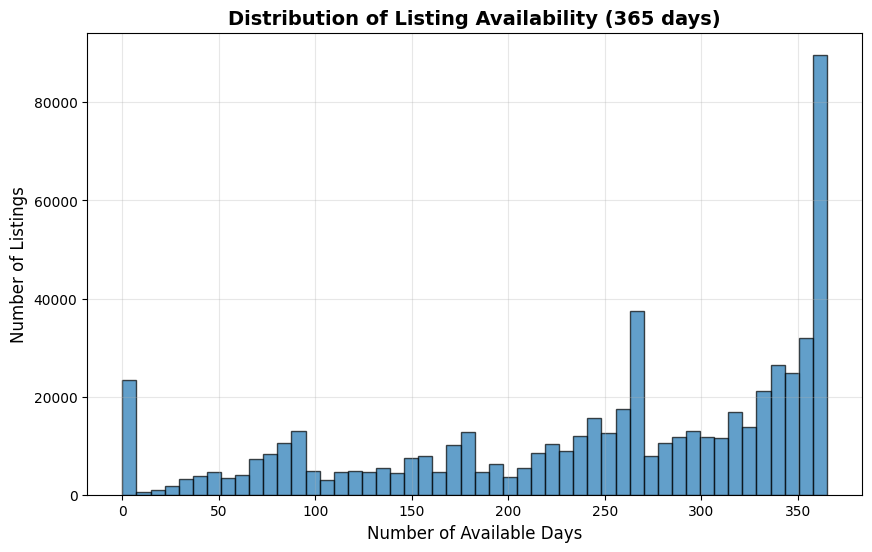

In [44]:
# Check the columns exist
print([col for col in merged.columns if 'availability' in col])

# See summary statistics
merged[['availability_30', 'availability_60', 'availability_365']].describe()

# See distribution with proper labels
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
merged['availability_365'].hist(bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Listing Availability (365 days)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Available Days', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [45]:
# Calculate occupancy rate
merged['occupancy_rate'] = (365 - merged['availability_365']) / 365

# Find most/least available listings
merged.nlargest(10, 'occupancy_rate')[['name', 'occupancy_rate']]

,name,occupancy_rate
65,"Easy going landlord,easy place",1.0
66,modern-style apartment in Bangkok,1.0
108,Luxury@swimpool/FreeWiFi/nearJJMkt,1.0
338,Chic two bedroom for Monthly rental,1.0
339,Chic two bedroom for Monthly rental,1.0
340,Chic two bedroom for Monthly rental,1.0
341,Chic two bedroom for Monthly rental,1.0
342,Chic two bedroom for Monthly rental,1.0
343,Chic two bedroom for Monthly rental,1.0
344,Chic two bedroom for Monthly rental,1.0


In [47]:
# Assuming your dataframe is 'df' and the column with >365 days is 'total_availability'
# First, isolate the listings with unusual availability
anomalies_df = merged[merged['availability_365'] > 365].copy()

# Define the conditions based on your columns
conditions = [
    # 1. Abandoned / Dead Listings: No recent activity or revenue
    (anomalies_df['number_of_reviews_ltm'] == 0) & (anomalies_df['estimated_revenue_l365d'] == 0),
    
    # 2. Multi-Unit / Highly Active: Lots of availability BUT also high occupancy/reviews
    (anomalies_df['estimated_occupancy_l365d'] > 0.60) & (anomalies_df['number_of_reviews_ltm'] > 10),
    
    # 3. Unpopular / Overpriced: Low occupancy but still gets occasional reviews
    (anomalies_df['estimated_occupancy_l365d'] < 0.15) & (anomalies_df['number_of_reviews_ltm'] > 0),
    
    # 4. Previously active, now dead
    (anomalies_df['number_of_reviews_ltm'] == 0) & (anomalies_df['number_of_reviews_ly'] > 0)
]

# Define the category names matching the conditions
categories = [
    'Abandoned/Inactive', 
    'Suspected Multi-Unit/Hotel', 
    'Low Demand/Overpriced',
    'Recently Abandoned'
]

# Create a new column to classify the listings, defaulting to 'Other' if no conditions are met
anomalies_df['anomaly_reason'] = np.select(conditions, categories, default='Other')

# View the results to see why your listings have >365 days of availability
print(anomalies_df['anomaly_reason'].value_counts())


Series([], Name: count, dtype: int64)


In [50]:
# 1. Debugging: Safely convert to numeric in case it was loaded as strings
merged['availability_365'] = pd.to_numeric(merged['availability_365'], errors='coerce')

# Print basic stats to understand the column's actual bounds
print("Max Availability Value in dataset:", merged['availability_365'].max())

# 2. Adjusted Filter: Look for >= 365 to catch fully open calendars
anomalies_df = merged[merged['availability_365'] >= 365].copy()

# Print the total count to ensure we actually captured the thousands of listings you saw
print(f"Total listings with >= 365 days availability: {len(anomalies_df)}\n")

# 3. Only run the classification if we found listings
if len(anomalies_df) > 0:
    conditions = [
        # Abandoned / Dead Listings: No recent activity or revenue
        (anomalies_df['number_of_reviews_ltm'] == 0) & (anomalies_df['estimated_revenue_l365d'] == 0),
        
        # Multi-Unit / Highly Active: Lots of availability BUT also high occupancy/reviews
        (anomalies_df['estimated_occupancy_l365d'] > 0.60) & (anomalies_df['number_of_reviews_ltm'] > 10),
        
        # Unpopular / Overpriced: Low occupancy but still gets occasional reviews
        (anomalies_df['estimated_occupancy_l365d'] < 0.15) & (anomalies_df['number_of_reviews_ltm'] > 0),
        
        # Previously active, now dead
        (anomalies_df['number_of_reviews_ltm'] == 0) & (anomalies_df['number_of_reviews_ly'] > 0)
    ]

    categories = [
        'Abandoned/Inactive', 
        'Suspected Multi-Unit/Hotel', 
        'Low Demand/Overpriced',
        'Recently Abandoned'
    ]

    anomalies_df['anomaly_reason'] = np.select(conditions, categories, default='Other')
    
    # View the categorized breakdown
    print("Reason Breakdown:")
    print(anomalies_df['anomaly_reason'].value_counts())
else:
    print("No listings found with availability >= 365. Check the column for missing values or different scale.")



Max Availability Value in dataset: 365
Total listings with >= 365 days availability: 24927

Reason Breakdown:
anomaly_reason
Other                         10198
Suspected Multi-Unit/Hotel     8929
Abandoned/Inactive             5535
Recently Abandoned              265
Name: count, dtype: int64


In [ ]:
is_active = (merged['number_of_reviews_ltm'] > 0) | (merged['estimated_revenue_l365d'] > 0)

# Split the dataset
active_listings_df = merged[is_active].copy()
inactive_listings_df = merged[~is_active].copy()

# Drop scraped calendar metadata from the active listings dataframe
active_listings_df = active_listings_df.drop(columns=[
    'calendar_updated',
    'calendar_last_scraped',
    'scrape_id'
], errors='ignore')

# Compare the impact on your metrics
print("--- Dataset Breakdown ---")
print(f"Total Original Listings: {len(merged)}")
print(f"Active Market Listings: {len(active_listings_df)}")
print(f"Inactive/Abandoned Listings: {len(inactive_listings_df)}\n")

print("--- Comparing the Unfiltered Dataset vs. The Active Market ---")
print(f"Average Revenue (Including Dead Listings): ${merged['estimated_revenue_l365d'].mean():.2f}")
print(f"Average Revenue (Active Listings Only):  ${active_listings_df['estimated_revenue_l365d'].mean():.2f}")

print("\n--- Removing abandoned listing Impact on Average Occupancy ---")
print(f"Average Occupancy (All Listings): {merged['estimated_occupancy_l365d'].mean():.1%}")
print(f"Average Occupancy (Active Only):  {active_listings_df['estimated_occupancy_l365d'].mean():.1%}")





--- Dataset Breakdown ---
Total Original Listings: 593423
Active Market Listings: 540059
Inactive/Abandoned Listings: 53364

--- Comparing the Unfiltered Dataset vs. The Active Market ---
Average Revenue (Including Dead Listings): $290533.09
Average Revenue (Active Listings Only):  $309711.61

--- Removing abandoned listing Impact on Average Occupancy ---
Average Occupancy (All Listings): 14960.9%
Average Occupancy (Active Only):  16439.2%


In [51]:
merged[['review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value']]

,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
0,4.86,4.95,4.82,4.97,4.91,4.66,4.75
1,4.86,4.95,4.82,4.97,4.91,4.66,4.75
2,4.86,4.95,4.82,4.97,4.91,4.66,4.75
3,4.86,4.95,4.82,4.97,4.91,4.66,4.75
4,4.86,4.95,4.82,4.97,4.91,4.66,4.75
...,...,...,...,...,...,...,...
593418,NaN,NaN,NaN,NaN,NaN,NaN,NaN
593419,NaN,NaN,NaN,NaN,NaN,NaN,NaN
593420,NaN,NaN,NaN,NaN,NaN,NaN,NaN
593421,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [59]:
print(active_listings_df.columns.tolist())

['listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'calendar_updated', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'first_review', 'last_review'

In [65]:
active_listings_df['listing_id']

69        5.568100e+04
70        5.568100e+04
71        5.568100e+04
72        5.568100e+04
73        5.568100e+04
              ...     
593275    1.513438e+18
593276    1.513438e+18
593322    1.513813e+18
593333    1.513848e+18
593357    1.516489e+18
Name: listing_id, Length: 540059, dtype: float64

In [66]:
from pathlib import Path

active_path = Path('data/active_listings.csv')
inactive_path = Path('data/inactive_listings.csv')

if not active_path.exists():
    active_listings_df.to_csv(active_path, index=False)
    print(f"Saved {active_path}")
else:
    print(f"Skipped saving {active_path}: file already exists")

if not inactive_path.exists():
    inactive_listings_df.to_csv(inactive_path, index=False)
    print(f"Saved {inactive_path}")
else:
    print(f"Skipped saving {inactive_path}: file already exists")

Saved data/active_listings.csv
Saved data/inactive_listings.csv
